El presente notebook muestra los resultados de la implementación de un modelo de redes neruonales convolucionales con la implementación de técnicas de regularización, con un total de 6 capas.

Importación de librerías

In [1]:
import os
import numpy as np
from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Importa función para dividir datos en entrenamiento y prueba
from tensorflow.keras.models import Model, Sequential # Importa la clase Model de Keras
from tensorflow.keras.layers import Conv2D, Input, BatchNormalization,MaxPooling2D, Flatten, Dense, Dropout, UpSampling2D, Conv2DTranspose, Concatenate, Activation # Importa capas de Keras para construir el modelo
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler  # Importa el callback
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsolutePercentageError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2025-10-30 21:15:46.984532: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-30 21:15:47.065725: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-30 21:15:49.382583: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Función de redimensionamiento de imagenes

In [2]:
# Función de redimensionado
def resize_npy_images(d_original, d_reducida, new_size):  # Define función para redimensionar imágenes .npy
    if not os.path.exists(d_reducida):  # Si el directorio reducido no existe
        os.makedirs(d_reducida)  # Lo crea
    for filename in os.listdir(d_original):  # Recorre los archivos en el directorio original
        if filename.lower().endswith('.npy'):  # Si el archivo es .npy
            img_path = os.path.join(d_original, filename)  # Construye la ruta completa del archivo
            img_array = np.load(img_path)  # Carga el array de la imagen
             # Redimensionar usando PIL
            img_resized = np.array(Image.fromarray(img_array).resize(new_size, Image.LANCZOS))
            np.save(os.path.join(d_reducida, filename), img_resized)


In [3]:
#Función para visualizar imagenes

def mostrar_resultados(X, y, y_pred, n=5, cmap='viridis',
                       titulo_general="Comparación de Resultados",
                       xlabel="Eje X (pixeles)", ylabel="Eje Y (pixeles)"):
    """
    Muestra comparaciones entre imágenes de entrada, reales y predichas.

    Parámetros:
        X (numpy array): Entradas (ej. [num_samples, h, w, 1]).
        y (numpy array): Valores reales (targets).
        y_pred (numpy array): Predicciones del modelo.
        n (int): Número de ejemplos a mostrar.
        cmap (str): Mapa de color para mostrar las imágenes.
        titulo_general (str): Título general de la figura.
        xlabel (str): Etiqueta para el eje X.
        ylabel (str): Etiqueta para el eje Y.
    """
    # Ajustar n si es mayor al número de ejemplos disponibles
    n = min(n, len(X))

    fig, axs = plt.subplots(n, 3, figsize=(12, 3 * n))
    fig.suptitle(titulo_general, fontsize=16, y=1.02)  # título principal arriba

    for i in range(n):
        # Entrada
        axs[i, 0].imshow(X[i, ..., 0], cmap=cmap)
        axs[i, 0].set_title(f'Entrada t={i}')
        axs[i, 0].set_xlabel(xlabel)
        axs[i, 0].set_ylabel(ylabel)

        # Real
        axs[i, 1].imshow(y[i, ..., 0], cmap=cmap)
        axs[i, 1].set_title(f'Real t+1={i+1}')
        axs[i, 1].set_xlabel(xlabel)
        axs[i, 1].set_ylabel(ylabel)

        # Predicción
        axs[i, 2].imshow(y_pred[i, ..., 0], cmap=cmap)
        axs[i, 2].set_title(f'Predicción t+1={i+1}')
        axs[i, 2].set_xlabel(xlabel)
        axs[i, 2].set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()

In [4]:
# Directorio con imagenes en tamaño original y  tamaño reducido
d_original = 'E:/bandas/banda13/ene_may_5m'
d_reducida = 'E:/bandas/banda13/ene_may_5m_reducida'

#Llamado de función para redimensionar imágenes
resize_npy_images(d_original, d_reducida, new_size=(480, 480))

# Cargar las imágenes
file_list = sorted([f for f in os.listdir(d_reducida) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images = [np.load(os.path.join(d_reducida, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images = [(img - global_min) / (global_max - global_min + 1e-8) for img in images]
images = [np.clip(img, 0, 1) for img in images]

X = np.array(images[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y = np.array(images[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y.shape}")  # Imprime la forma del array de salida

Procesando 3618 imágenes
Forma de X: (3617, 480, 480, 1)
Forma de y: (3617, 480, 480, 1)


Creación de un modelo simple de redes neuronales convolucionales

In [5]:
semilla = 42
tf.random.set_seed(semilla)

model2 = Sequential([
    # Encoder
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=X.shape[1:]),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Bottleneck
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # Decoder
    UpSampling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),

    # Output
    Conv2D(1, (1, 1), activation='sigmoid', padding='same')
])

model2.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
    )

print("Resumen del modelo:")
model2.summary()

# =====================================================
# CALLBACKS
# =====================================================
checkpoint = ModelCheckpoint(
    filepath="modelo2_best.h5",
    monitor="val_loss",  # Monitoreamos validación, no entrenamiento
    save_best_only=True,
    mode="min",
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# =====================================================
# DIVISIÓN CRONOLÓGICA DE DATOS (SERIE DE TIEMPO)
# =====================================================
porc_validacion = 0.2
split_index = int(len(X) * (1 - porc_validacion))

X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

print(f"Tamaño entrenamiento: {len(X_train)} muestras")
print(f"Tamaño validación: {len(X_val)} muestras")

# Entrenamiento
print("Iniciando entrenamiento")
history2 = model2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=4,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("¡Entrenamiento completado!")
print(f"Pérdida final: {history2.history['loss'][-1]:.4f}")

Resumen del modelo:


c:\Users\jhona\python1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 480, 480, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 240, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 240, 240, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 120, 120, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 240, 240, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 240, 240, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 240, 240, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 480, 480, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 480, 480, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 480, 480, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 480, 480, 1)    │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 186,241 (727.50 KB)

...

Tamaño entrenamiento: 2893 muestras
Tamaño validación: 724 muestras
Iniciando entrenamiento
Epoch 1/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - loss: 0.0089 - mean_absolute_percentage_error: 19.6185 - root_mean_squared_error: 0.0917
Epoch 1: val_loss improved from None to 0.00882, saving model to modelo2_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 499s 687ms/step - loss: 0.0067 - mean_absolute_percentage_error: 18.0100 - root_mean_squared_error: 0.0817 - val_loss: 0.0088 - val_mean_absolute_percentage_error: 33.2827 - val_root_mean_squared_error: 0.0939
Epoch 2/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 0.0059 - mean_absolute_percentage_error: 16.9136 - root_mean_squared_error: 0.0767
Epoch 2: val_loss improved from 0.00882 to 0.00722, saving model to modelo2_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 516s 713ms/step - loss: 0.0059 - mean_absolute_percentage_error: 17.0998 - root_mean_squared_error: 0.0770 - val_loss: 0.0072 - val_mean_absolute_percentage_error: 25.6129 - val_root_mean_squared_error: 0.0850
Epoch 3/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - loss: 0.0057 - mean_absolute_percentage_error: 16.7276 - root_mean_squared_error: 0.0758
Epoch 3: val_loss improved from 0.00722 to 0.00713, saving model to modelo2_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 512s 708ms/step - loss: 0.0058 - mean_absolute_percentage_error: 17.0077 - root_mean_squared_error: 0.0764 - val_loss: 0.0071 - val_mean_absolute_percentage_error: 24.8485 - val_root_mean_squared_error: 0.0844
Epoch 4/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - loss: 0.0057 - mean_absolute_percentage_error: 16.7012 - root_mean_squared_error: 0.0755
Epoch 4: val_loss improved from 0.00713 to 0.00661, saving model to modelo2_best.h5


724/724 ━━━━━━━━━━━━━━━━━━━━ 516s 713ms/step - loss: 0.0058 - mean_absolute_percentage_error: 16.9974 - root_mean_squared_error: 0.0761 - val_loss: 0.0066 - val_mean_absolute_percentage_error: 22.2789 - val_root_mean_squared_error: 0.0813
Epoch 5/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 679ms/step - loss: 0.0056 - mean_absolute_percentage_error: 16.5908 - root_mean_squared_error: 0.0751
Epoch 5: val_loss did not improve from 0.00661
724/724 ━━━━━━━━━━━━━━━━━━━━ 516s 713ms/step - loss: 0.0057 - mean_absolute_percentage_error: 16.8986 - root_mean_squared_error: 0.0757 - val_loss: 0.0066 - val_mean_absolute_percentage_error: 22.6511 - val_root_mean_squared_error: 0.0814
Epoch 6/50
724/724 ━━━━━━━━━━━━━━━━━━━━ 0s 676ms/step - loss: 0.0056 - mean_absolute_percentage_error: 16.5430 - root_mean_squared_error: 0.0746
Epoch 6: val_loss did not improve from 0.00661
724/724 ━━━━━━━━━━━━━━━━━━━━ 514s 710ms/step - loss: 0.0057 - mean_absolute_percentage_error: 16.8217 - root_mean_squared_error: 0.0752 - 

Valores de las metricas

In [6]:
# Obtener las métricas del modelo en el conjunto de entrenamiento
loss, rmse, mape = model2.evaluate(X_train, y_train, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 86s 935ms/step - loss: 0.0050 - mean_absolute_percentage_error: 15.7925 - root_mean_squared_error: 0.0707
Pérdida (MSE): 0.0050
RMSE: 0.0707
MAPE: 15.7925


In [7]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model2.evaluate(X_val, y_val, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 896ms/step - loss: 0.0066 - mean_absolute_percentage_error: 22.2789 - root_mean_squared_error: 0.0813
Pérdida (MSE): 0.0066
RMSE: 0.0813
MAPE: 22.2789


RESUMEN DE MÉTRICAS
Entrenamiento - Loss final: 0.0050, RMSE final: 0.0710, MAPE final: 15.5831
Validación    - Loss final: 0.0072, RMSE final: 0.0846, MAPE final: 26.2193


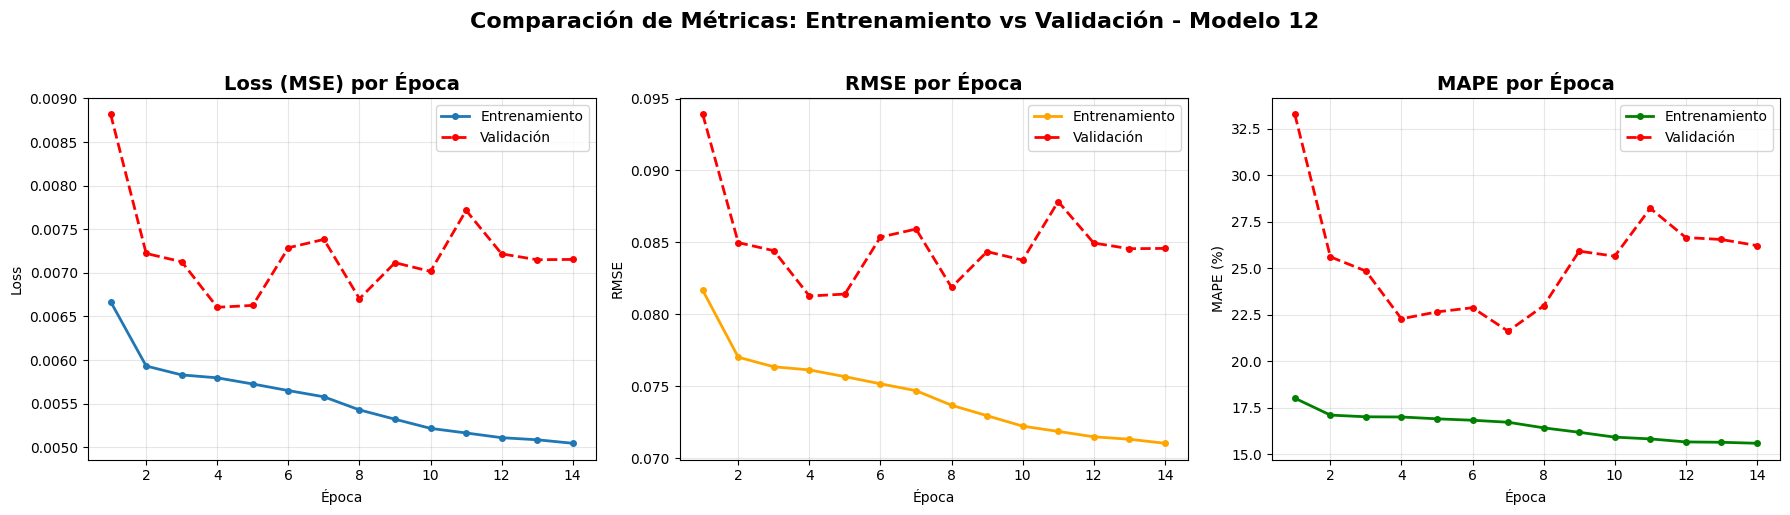

In [8]:
import matplotlib.pyplot as plt

# Extraer métricas del historial (entrenamiento y validación)
loss = history2.history['loss']
val_loss = history2.history['val_loss']

rmse = history2.history['root_mean_squared_error']
val_rmse = history2.history['val_root_mean_squared_error']

mape = history2.history['mean_absolute_percentage_error']
val_mape = history2.history['val_mean_absolute_percentage_error']

epochs = range(1, len(loss) + 1)

# Mostrar resumen final
print("=" * 50)
print("RESUMEN DE MÉTRICAS")
print("=" * 50)
print(f"Entrenamiento - Loss final: {loss[-1]:.4f}, RMSE final: {rmse[-1]:.4f}, MAPE final: {mape[-1]:.4f}")
print(f"Validación    - Loss final: {val_loss[-1]:.4f}, RMSE final: {val_rmse[-1]:.4f}, MAPE final: {val_mape[-1]:.4f}")
print("=" * 50)

# =============================================================================
# VISUALIZACIÓN DE MÉTRICAS
# =============================================================================

plt.figure(figsize=(18, 5))

# Gráfico 1: Loss (MSE)
plt.subplot(1, 3, 1)
plt.plot(epochs, loss, marker='o', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_loss, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('Loss (MSE) por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 2: RMSE
plt.subplot(1, 3, 2)
plt.plot(epochs, rmse, marker='o', color='orange', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_rmse, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('RMSE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('RMSE')
plt.grid(True, alpha=0.3)
plt.legend()

# Gráfico 3: MAPE
plt.subplot(1, 3, 3)
plt.plot(epochs, mape, marker='o', color='green', label='Entrenamiento', linewidth=2, markersize=4)
plt.plot(epochs, val_mape, marker='o', linestyle='--', color='red', linewidth=2, markersize=4, label='Validación')
plt.title('MAPE por Época', fontsize=14, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('MAPE (%)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.suptitle('Comparación de Métricas: Entrenamiento vs Validación - Modelo 12',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Visualización de imagenes

91/91 ━━━━━━━━━━━━━━━━━━━━ 84s 926ms/step


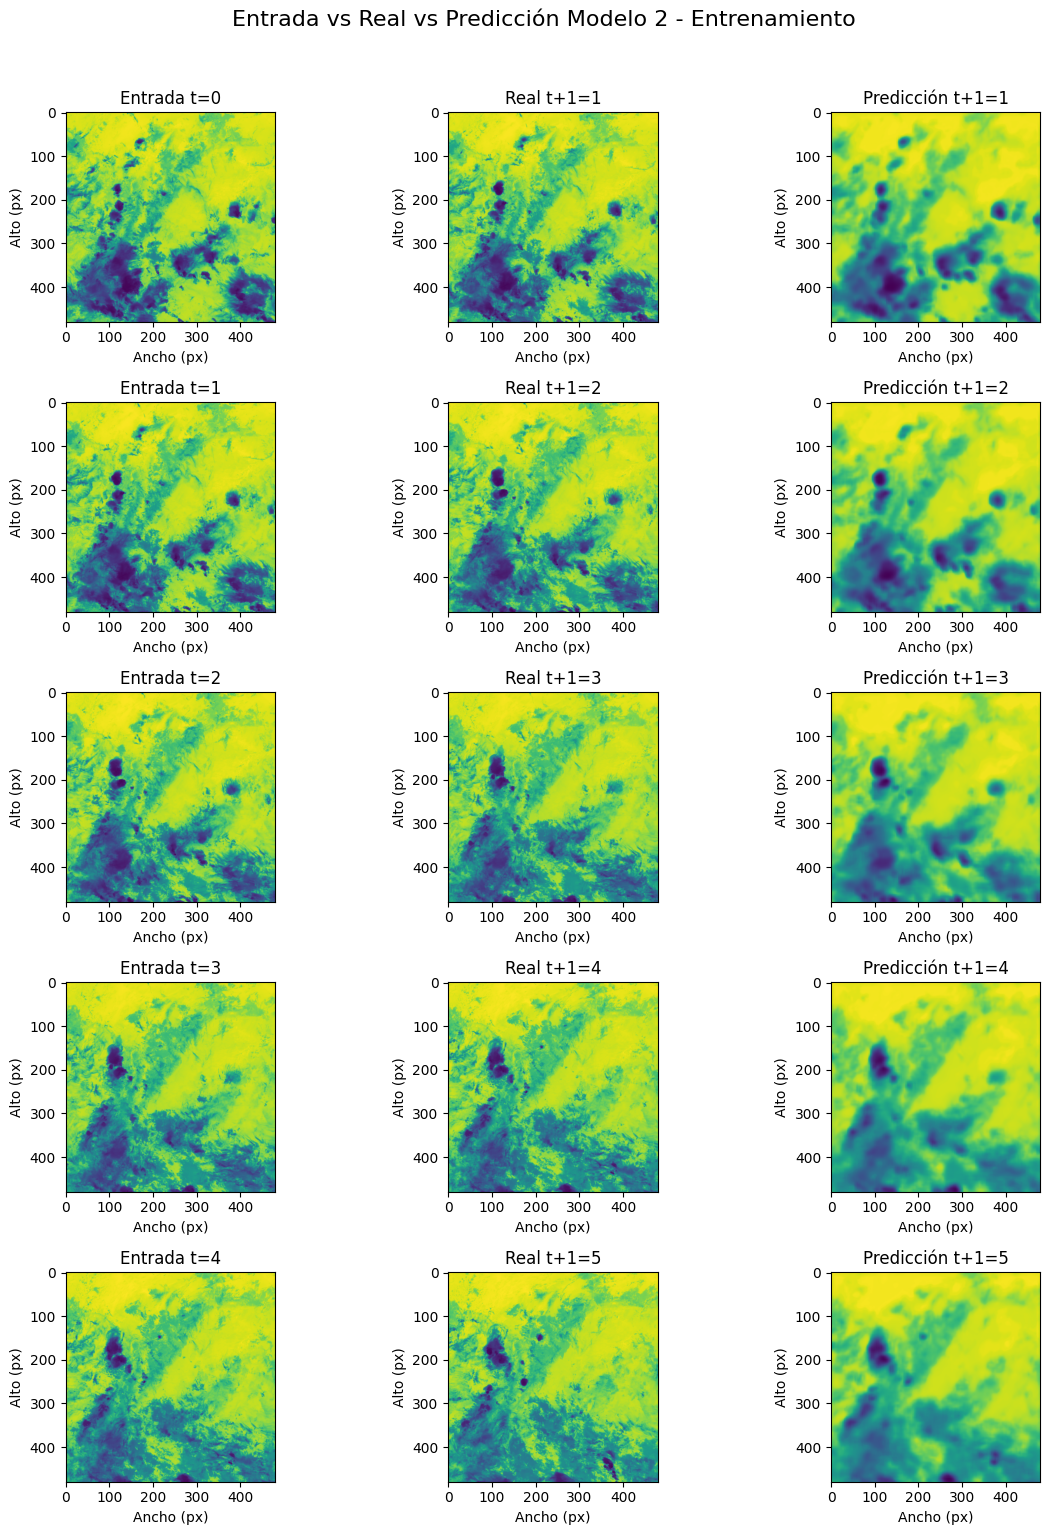

In [9]:
y_pred2 = model2.predict(X_train)  # Genera las predicciones
mostrar_resultados(
    X_train, y_train, y_pred2, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 2 - Entrenamiento",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

Prueba



In [4]:
# Directorio original y reducido
d_jun_1m = '/home/fisica/bandas/banda13/jun_1m'
d_jun_1m_red = '/home/fisica/bandas/banda13/jun_1m_red'


# Se llama a la función para redimensionar imágenes
resize_npy_images(d_jun_1m, d_jun_1m_red, new_size=(480, 480))  # Llama la función para redimensionar imágenes a 480x480

# Cargar imágenes
file_list = sorted([f for f in os.listdir(d_jun_1m_red) if f.endswith('.npy')])  # Lista y ordena los archivos .npy
#file_list = file_list[:23]  # Selecciona solo los primeros 23 archivos
print(f"Procesando {len(file_list)} imágenes")  # Imprime la cantidad de imágenes procesadas

images_test = [np.load(os.path.join(d_jun_1m_red, f)) for f in file_list]  # Carga los arrays de las imágenes seleccionadas

# Normalización simple

# Normalización
all_pixels = np.concatenate([img.flatten() for img in images_test])
global_min, global_max = np.min(all_pixels), np.max(all_pixels)

images_test = [(img - global_min) / (global_max - global_min + 1e-8) for img in images_test]
images_test = [np.clip(img, 0, 1) for img in images_test]


X_test = np.array(images_test[:-1])[..., np.newaxis]  # img_t  # Crea array de entrada con dimensión de canal
y_test = np.array(images_test[1:])[..., np.newaxis]   # img_t+1  # Crea array de salida (siguiente imagen) con canal

print(f"Forma de X: {X_test.shape}")  # Imprime la forma del array de entrada
print(f"Forma de y: {y_test.shape}")  # Imprime la forma del array de salida

Procesando 716 imágenes
Forma de X: (715, 480, 480, 1)
Forma de y: (715, 480, 480, 1)


2025-10-30 21:17:23.278737: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2025-10-30 21:17:24.432463: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 658944000 exceeds 10% of free system memory.
2025-10-30 21:17:25.833780: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 943718400 exceeds 10% of free system memory.
2025-10-30 21:17:26.858439: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 235929600 exceeds 10% of free system memory.
2025-10-30 21:17:27.178378: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 471859200 exceeds 10% of free system memory.
2025-10-30 21:17:27.759886: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 117964800 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 176s 8s/step


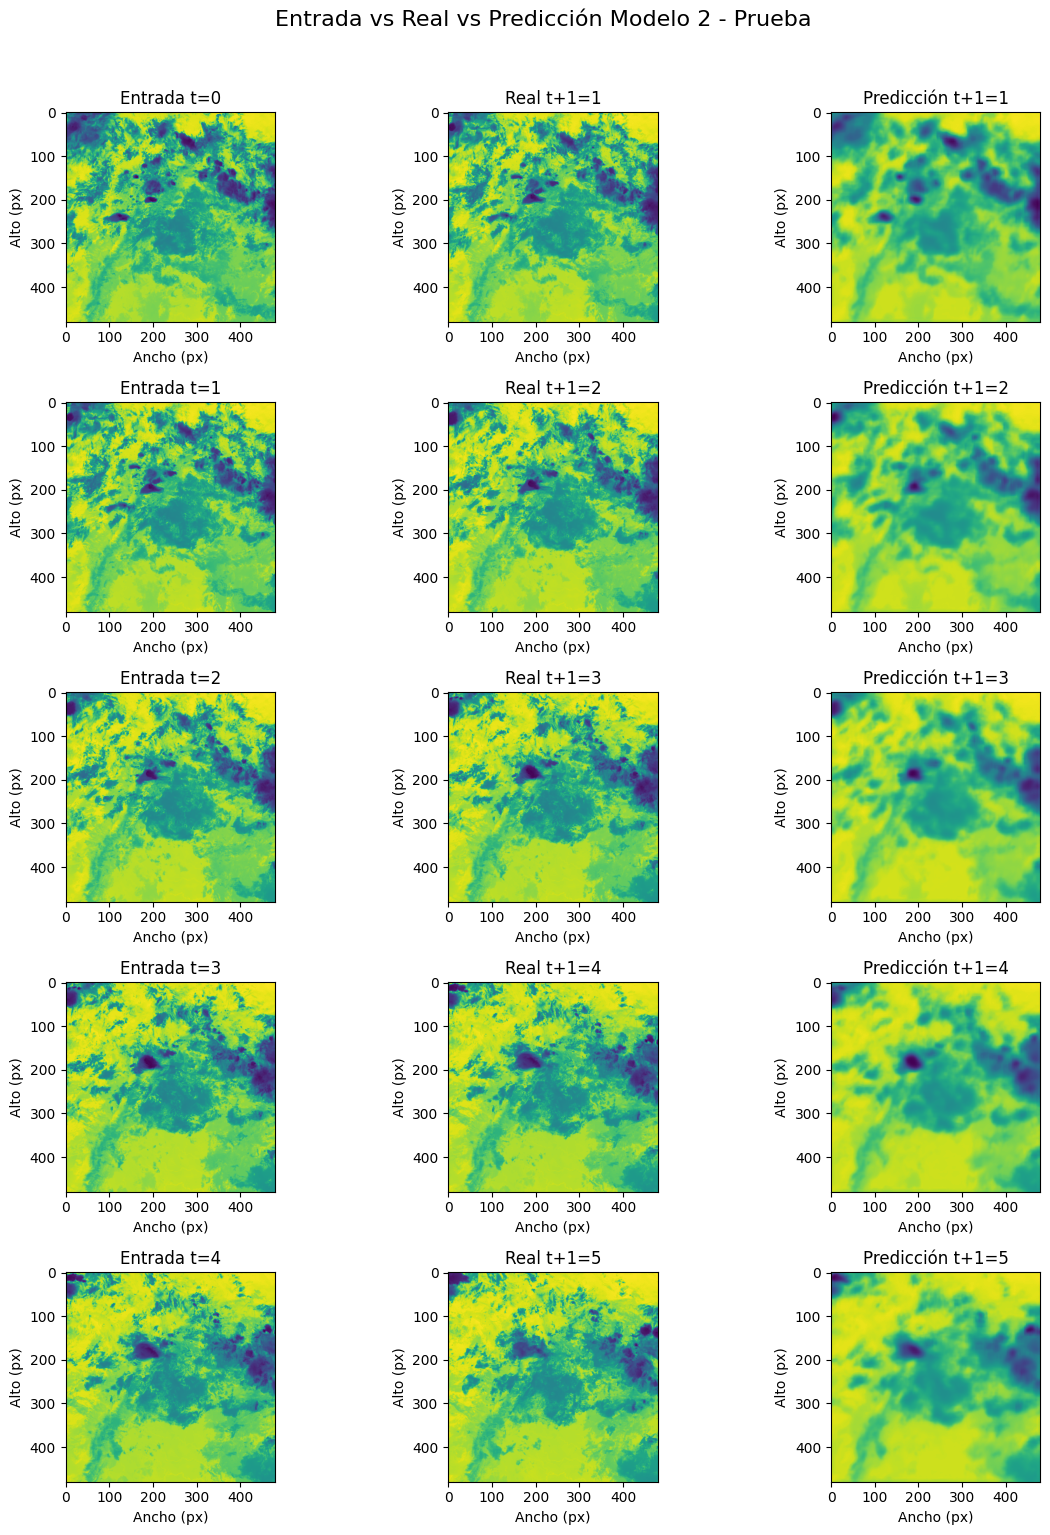

In [5]:
from tensorflow.keras.models import load_model
# Cargar el mejor modelo guardado
modelo_cargado = load_model("modelo2_best.h5", compile=False)

y_pred_test = modelo_cargado.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 2 - Prueba",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)

In [6]:
# Obtener las métricas del modelo en el conjunto de prueba
modelo_cargado.compile(
    optimizer="adam",
    loss="mse",
    metrics=[RootMeanSquaredError(), MeanAbsolutePercentageError()]
)

loss, rmse, mape = modelo_cargado.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 177s 8s/step - loss: 0.0083 - mean_absolute_percentage_error: 23.5516 - root_mean_squared_error: 0.0909
Pérdida (MSE): 0.0083
RMSE: 0.0909
MAPE: 23.5516


Metricas de prueba

In [12]:
# Obtener las métricas del modelo en el conjunto de validación
loss, rmse, mape = model2.evaluate(X_test, y_test, verbose=1)
print(f"Pérdida (MSE): {loss:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 844ms/step - loss: 0.0052 - mean_absolute_percentage_error: 16.7377 - root_mean_squared_error: 0.0724
Pérdida (MSE): 0.0052
RMSE: 0.0724
MAPE: 16.7377


Visualización de imagenes con conjunto de validación

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 833ms/step


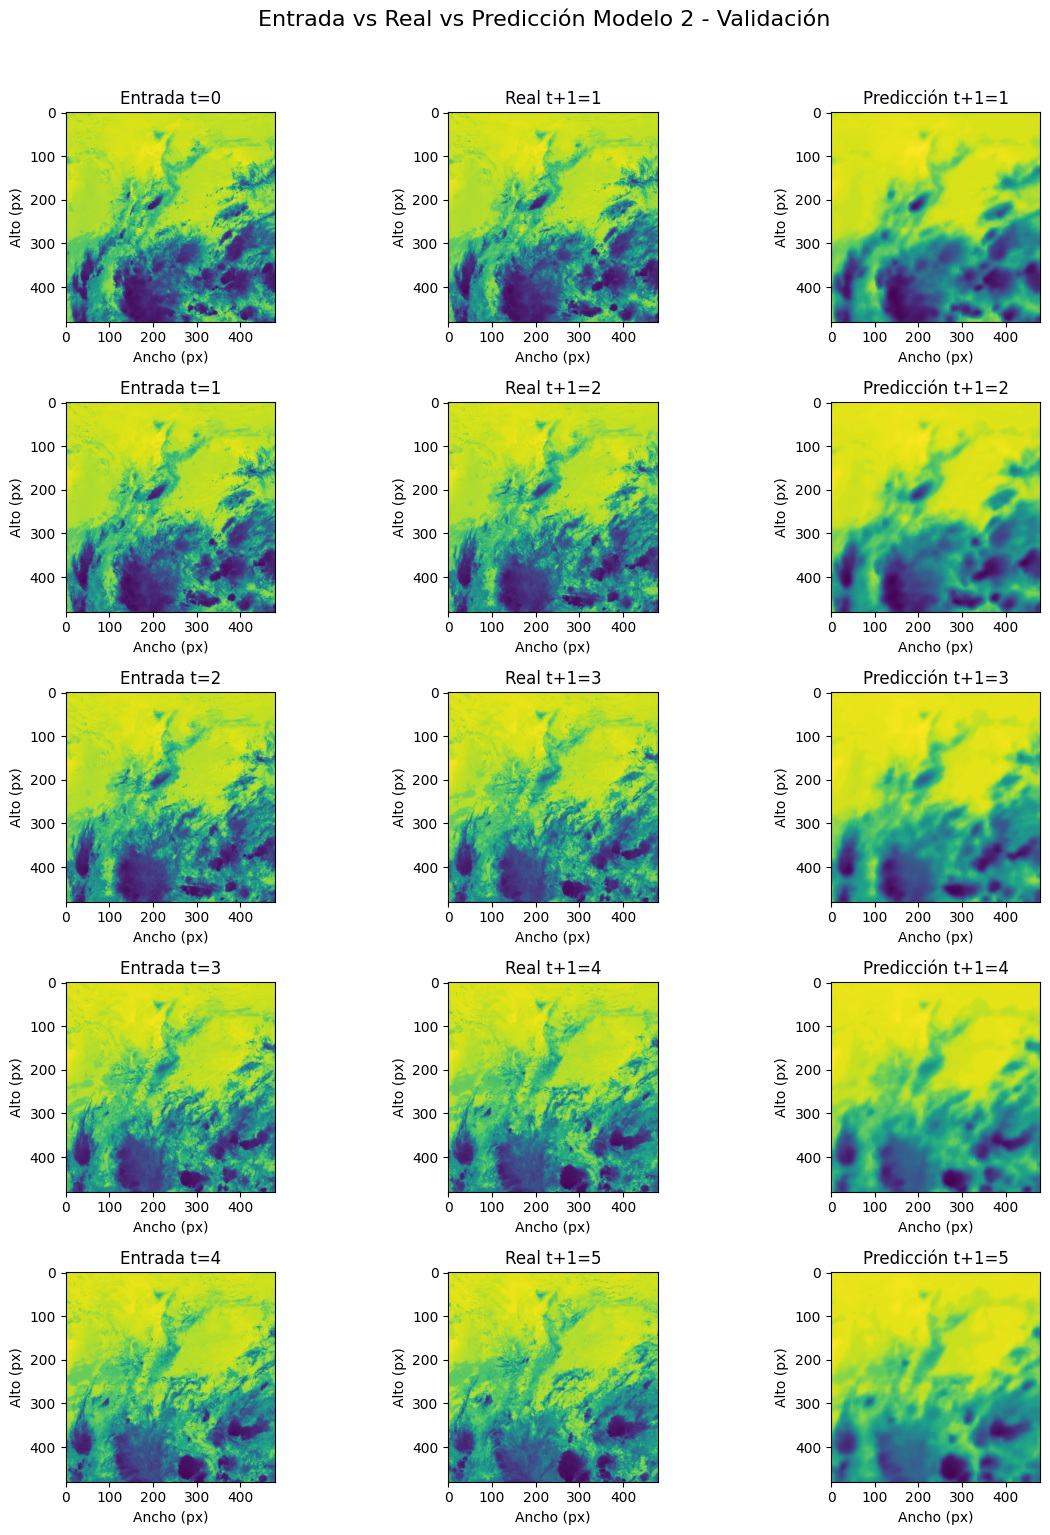

In [13]:
y_pred2_test = model2.predict(X_test)  # Genera las predicciones
mostrar_resultados(
    X_test, y_test, y_pred2_test, n=5,
    titulo_general="Entrada vs Real vs Predicción Modelo 2 - Validación",
    xlabel="Ancho (px)", ylabel="Alto (px)"
)